# 9.1 A Brief matplotlib API Primer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data=np.arange(10)

In [3]:
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

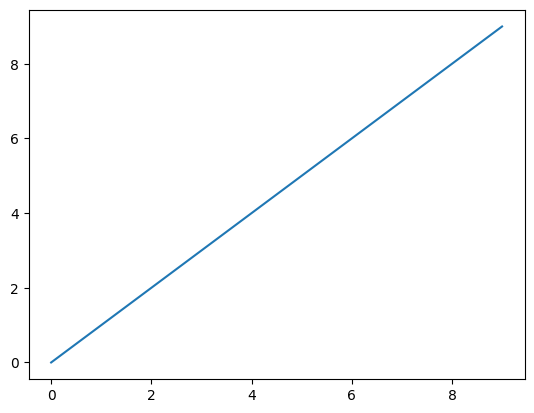

In [4]:
plt.plot(data)

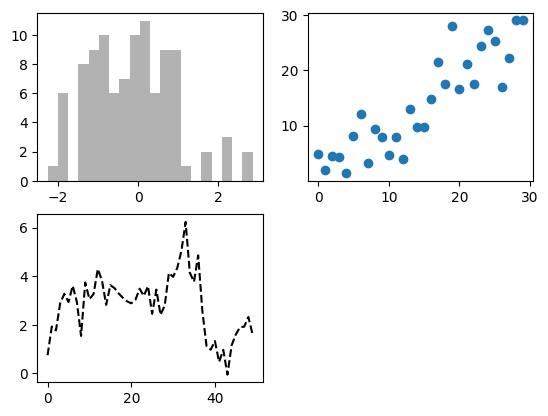

In [5]:
fig=plt.figure()
ax1=fig.add_subplot(2,2,1)
ax2=fig.add_subplot(2,2,2)
ax3=fig.add_subplot(2,2,3)

ax3.plot(np.random.standard_normal(50).cumsum(),color="black",linestyle="dashed")

ax1.hist(np.random.standard_normal(100),bins=20,color="black",alpha=0.3)

ax2.scatter(np.arange(30),np.arange(30)+3*np.random.standard_normal(30))

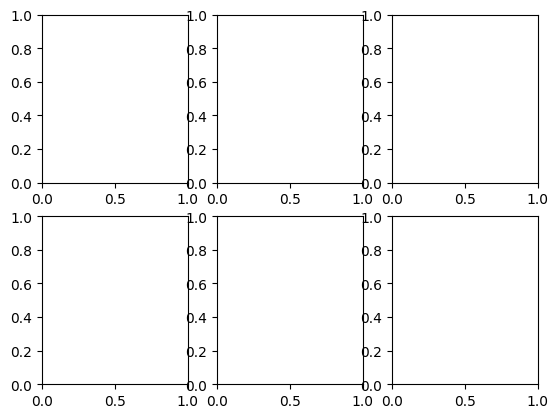

In [6]:
fig,axes=plt.subplots(2,3)

In [7]:
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

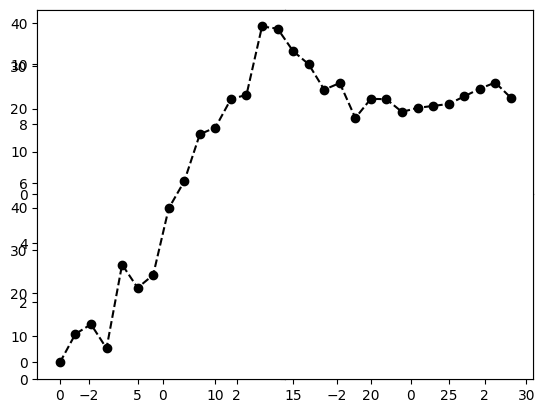

In [8]:
fig,axes=plt.subplots(2,2,sharex=True,sharey=True)
for i in range(2):
    for j in range(2):
        axes[i,j].hist(np.random.standard_normal(500),bins=50,color="black",alpha=0.5)

fig.subplots_adjust(wspace=0,hspace=0)

# Colors, Markers, and Line Styles
ax=fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color="black",linestyle="dashed",marker="o")

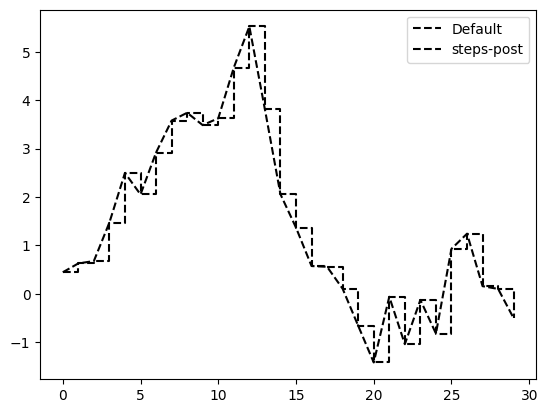

In [9]:
fig=plt.figure()
ax=fig.add_subplot()
data=np.random.standard_normal(30).cumsum()
ax.plot(data,color="black",linestyle="dashed",label="Default")
ax.plot(data,color="black",linestyle="dashed",drawstyle="steps-post",label="steps-post")
ax.legend()

# Ticks, Labels, and Legends

Text(0.5, 1.0, 'My First Matplotlib Plot')

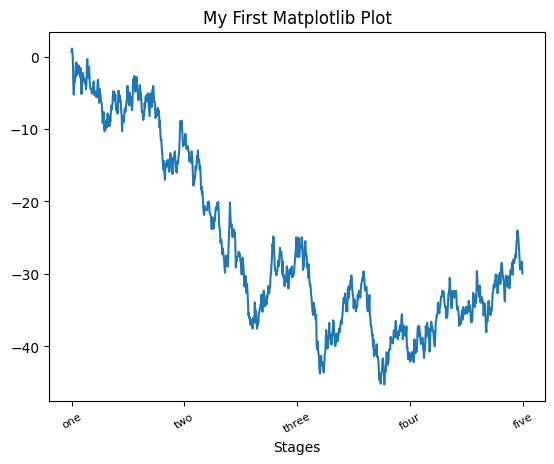

In [10]:
fig,ax=plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())

ticks=ax.set_xticks([0,250,500,750,1000])
labels=ax.set_xticklabels(["one","two","three","four","five"],rotation=30,fontsize=8)

ax.set_xlabel("Stages")
ax.set_title("My First Matplotlib Plot")

Adding legends

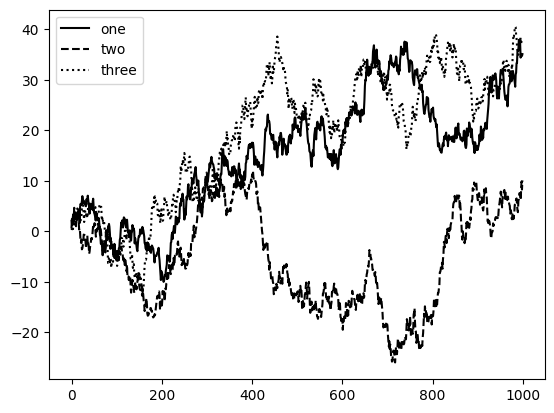

In [11]:
fig,ax=plt.subplots()
ax.plot(np.random.randn(1000).cumsum(),color="black",label="one")
ax.plot(np.random.randn(1000).cumsum(),color="black",linestyle="dashed",label="two")
ax.plot(np.random.randn(1000).cumsum(),color="black",linestyle="dotted",label="three")
ax.legend()

# Annotations and Drawing on a Subplot


In [12]:
from datetime import datetime

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

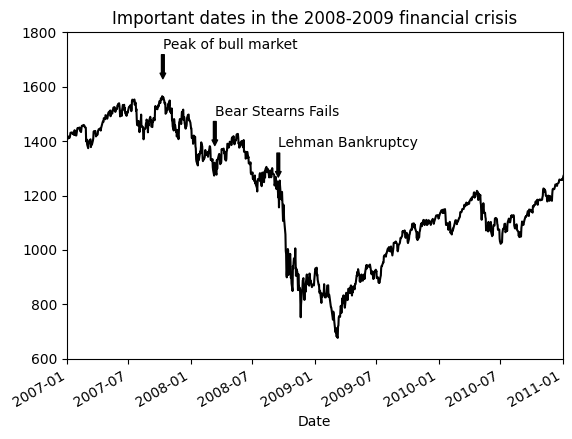

In [13]:
fig,ax=plt.subplots()
data=pd.read_csv("examples/spx.csv",index_col=0,parse_dates=True)
spx=data["SPX"]

spx.plot(ax=ax,color="black")

crisis_data=[
    (datetime(2007,10,11),"Peak of bull market"),
    (datetime(2008,3,12),"Bear Stearns Fails"),
    (datetime(2008,9,15),"Lehman Bankruptcy")
]

for date,label in crisis_data:
    ax.annotate(label,xy=(date,spx.asof(date)+75),
                xytext=(date,spx.asof(date)+225),
                arrowprops=dict(facecolor="black",headwidth=4,width=2,headlength=4),
                horizontalalignment="left",
                verticalalignment="top")

ax.set_xlim(["1/1/2007","1/1/2011"])
ax.set_ylim([600,1800])

ax.set_title("Important dates in the 2008-2009 financial crisis")

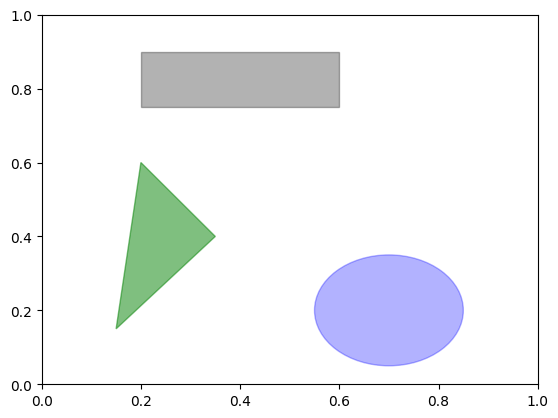

In [14]:
fig,ax=plt.subplots()
rect=plt.Rectangle((0.2,0.75),0.4,0.15,color="black",alpha=0.3)
circ=plt.Circle((0.7,0.2),0.15,color="blue",alpha=0.3)
pgon=plt.Polygon([[0.15,0.15],[0.35,0.4],[0.2,0.6]],
                 color="green",alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

# Saving Plots to File

In [15]:
fig.savefig("figpath.svg")

In [16]:
fig.savefig("figpath.png", dpi=400)

# matplotlib Configuration

In [17]:
plt.rc("figure",figsize=(10,10))

In [18]:
plt.rc("font", family="monospace", weight="bold", size=8)

# 9.2 Plotting with pandas and seaborn

Line Plots

<Axes: >

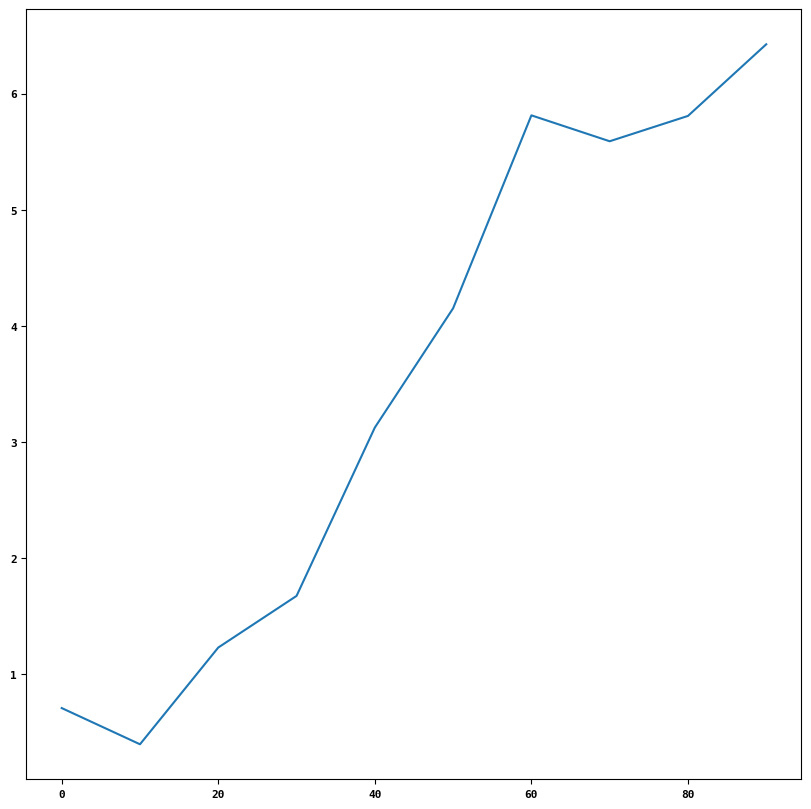

In [19]:
s=pd.Series(np.random.standard_normal(10).cumsum(),
            index=np.arange(0,100,10))
s.plot()

In [20]:
df=pd.DataFrame(np.random.standard_normal((10,4)).cumsum(0),
                columns=["A","B","C","D"],
                index=np.arange(0,100,10))

In [21]:
df

,A,B,C,D
0,-0.281331,0.595580,0.124910,-1.901945
10,-0.530366,1.892696,-0.447066,-0.765778
20,-0.327281,2.227627,-1.931343,-0.013692
30,-1.661777,1.656032,-3.565784,0.108355
40,-1.483179,3.231649,-2.867373,0.163451
50,-1.856935,4.639842,-3.239620,0.161412
60,-0.250659,3.756826,-3.045721,2.582972
70,-0.891723,2.435392,-2.487540,3.259734
80,-0.872469,2.576075,-2.452660,3.232175
90,-2.363146,3.221463,-3.332322,2.909962


In [22]:
plt.style.use("grayscale")

<Axes: >

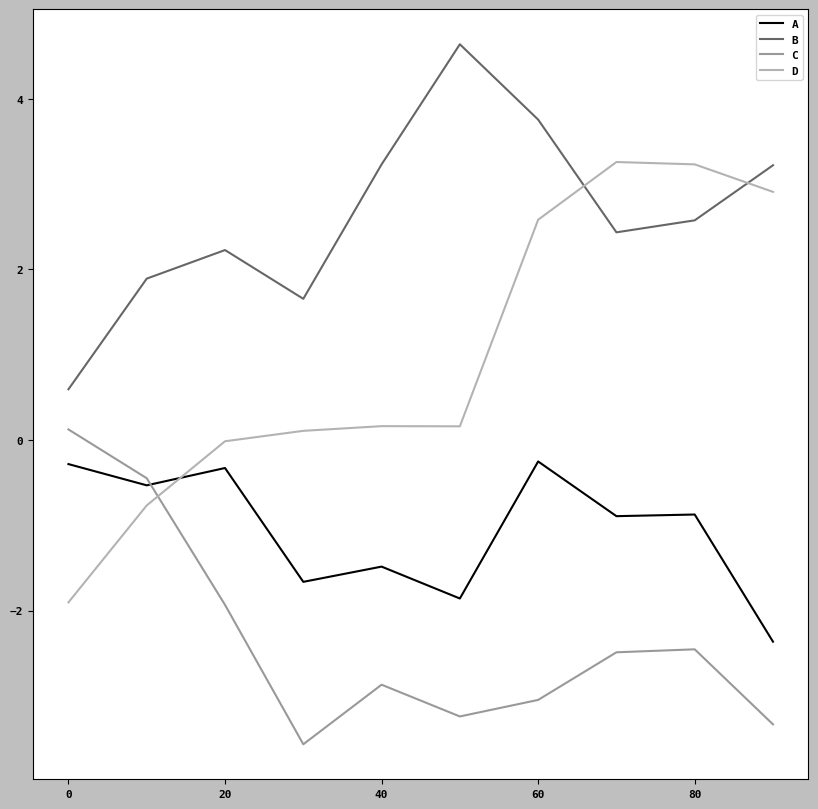

In [23]:
df.plot()

# Bar Plots

<Axes: >

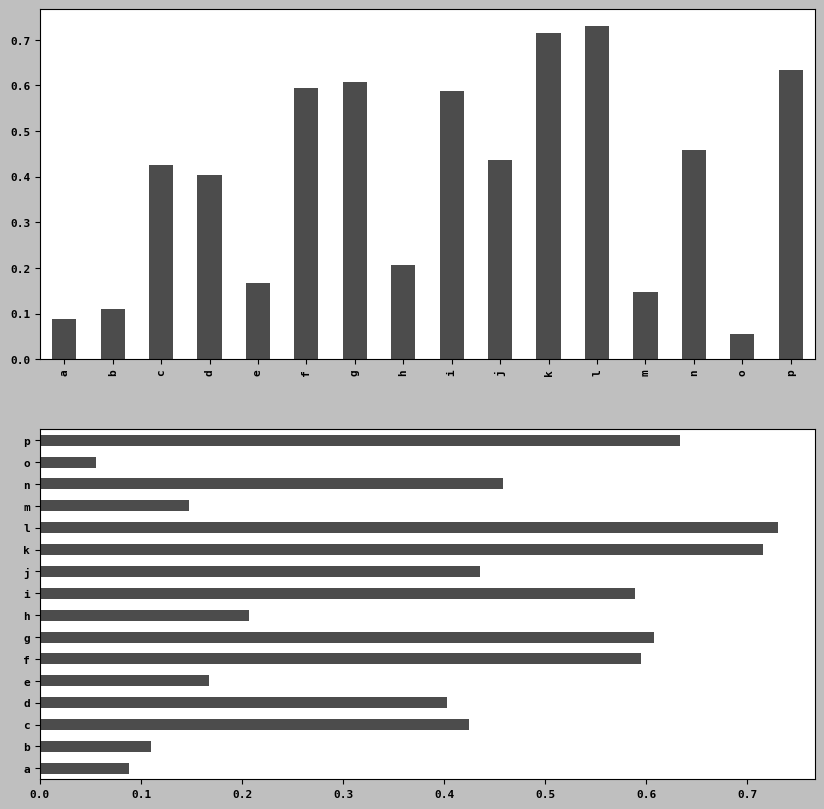

In [24]:
fig,axes=plt.subplots(2,1)
data=pd.Series(np.random.uniform(size=16),index=list("abcdefghijklmnop"))

data.plot.bar(ax=axes[0],color="black",alpha=0.7)

data.plot.barh(ax=axes[1],color="black",alpha=0.7)

In [25]:
df=pd.DataFrame(np.random.uniform(size=(6,4)),
                index=["one","two","three","four","five","six"],
                columns=pd.Index(["A","B","C","D"],
                                 name="Genus"))

In [26]:
df

Genus,A,B,C,D
one,0.472653,0.239947,0.044294,0.221961
two,0.060328,0.668828,0.598458,0.226172
three,0.164424,0.550793,0.984604,0.843337
four,0.847387,0.583843,0.222896,0.642604
five,0.305044,0.891088,0.747378,0.896746
six,0.390167,0.221101,0.815432,0.468354


<Axes: >

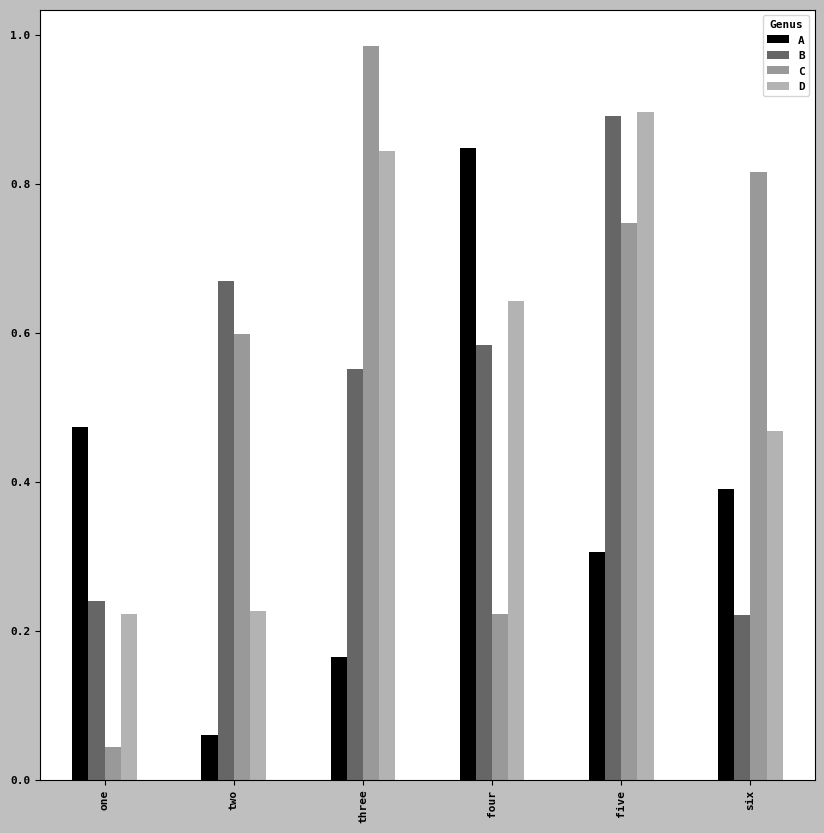

In [27]:
df.plot.bar()

<Axes: >

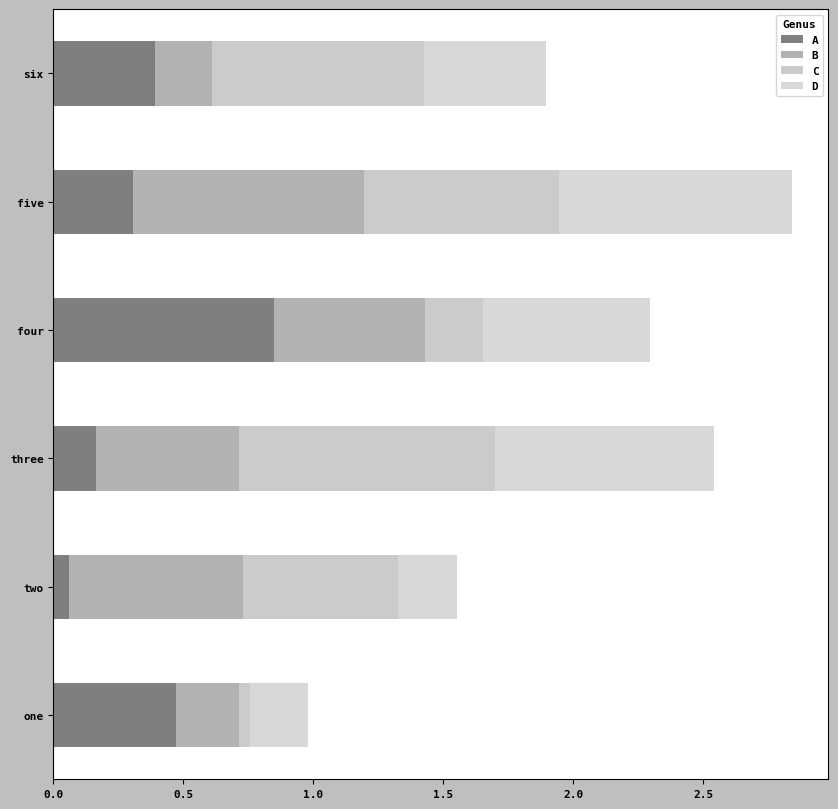

In [28]:
df.plot.barh(stacked=True,alpha=0.5)

In [29]:
tips=pd.read_csv("examples/tips.csv")

In [30]:
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


In [31]:
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [32]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   smoker      244 non-null    object 
 3   day         244 non-null    object 
 4   time        244 non-null    object 
 5   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 11.6+ KB


In [33]:
tips["day"]

0       Sun
1       Sun
2       Sun
3       Sun
4       Sun
       ... 
239     Sat
240     Sat
241     Sat
242     Sat
243    Thur
Name: day, Length: 244, dtype: object

In [34]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [35]:
party_counts=pd.crosstab(tips["day"],tips["size"])

In [36]:
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [37]:
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])

In [38]:
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [39]:
party_counts=party_counts.loc[:,2:5]

In [40]:
party_pcts=party_counts.div(party_counts.sum(axis="columns"),
                            axis="index")

In [41]:
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

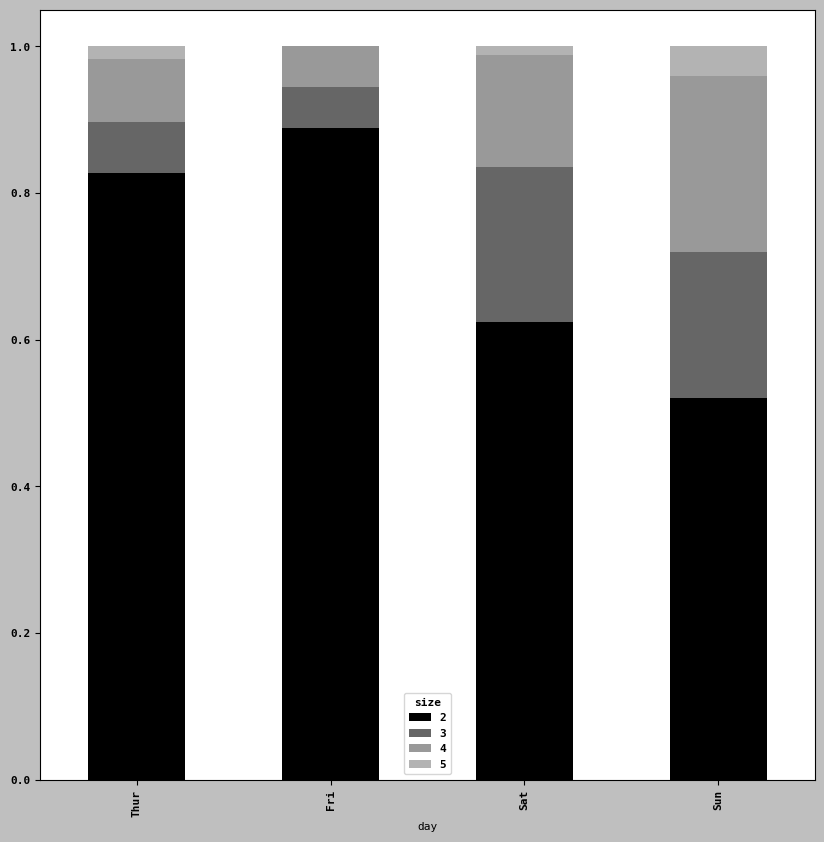

In [42]:
party_pcts.plot.bar(stacked=True)

In [43]:
import seaborn as sns

In [44]:
tips["tip_pct"]=tips["tip"]/(tips["total_bill"]-tips["tip"])

In [45]:
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

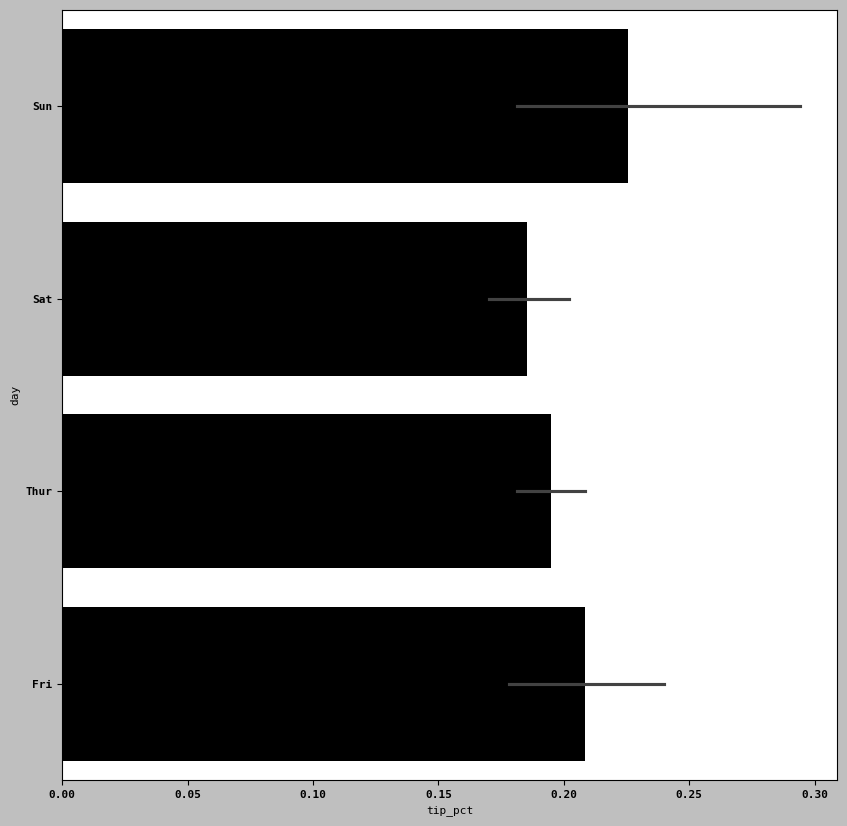

In [46]:
sns.barplot(x="tip_pct",y="day",data=tips,orient="h")

<Axes: xlabel='tip_pct', ylabel='day'>

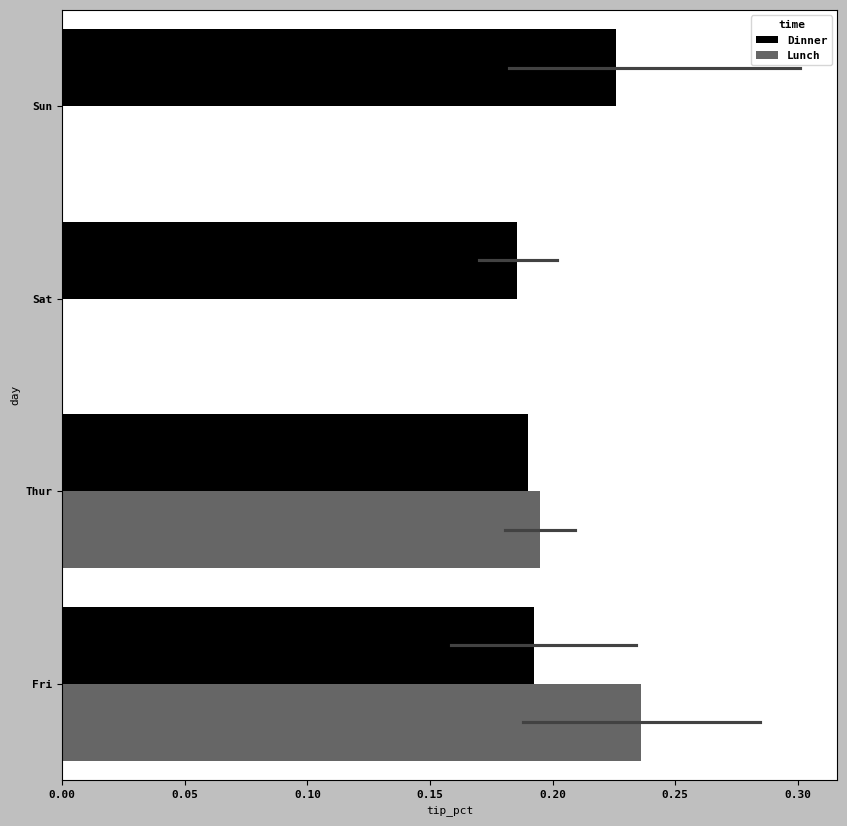

In [47]:
sns.barplot(x="tip_pct",y="day",data=tips,orient="h",hue="time")

In [48]:
sns.set_style("whitegrid")

In [49]:
sns.set_palette("Greys_r")

# Histograms and Density Plots

<Axes: ylabel='Frequency'>

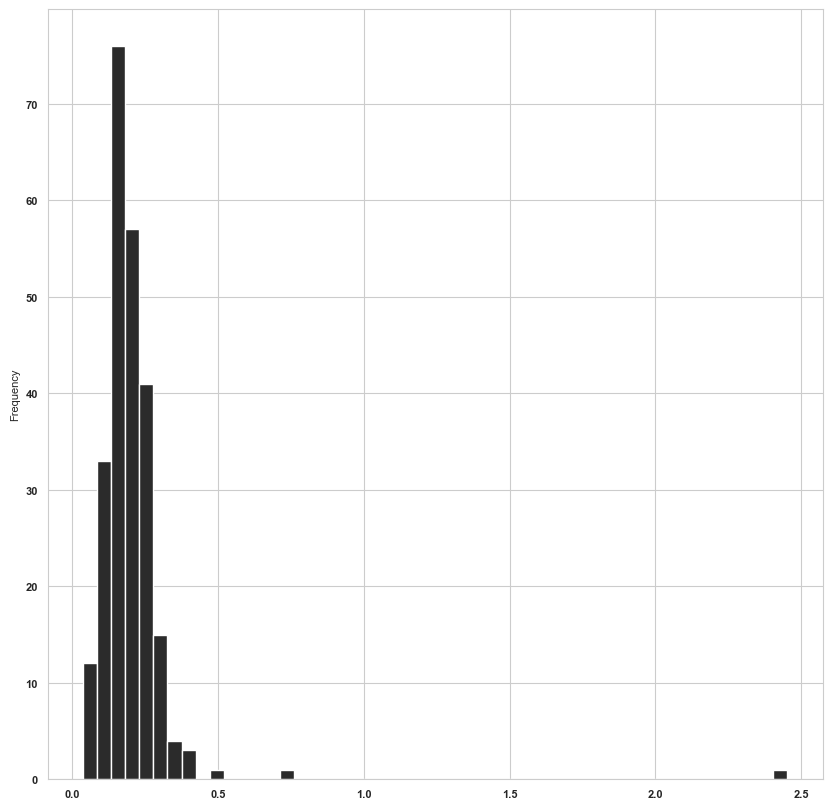

In [50]:
tips["tip_pct"].plot.hist(bins=50)

<Axes: ylabel='Density'>

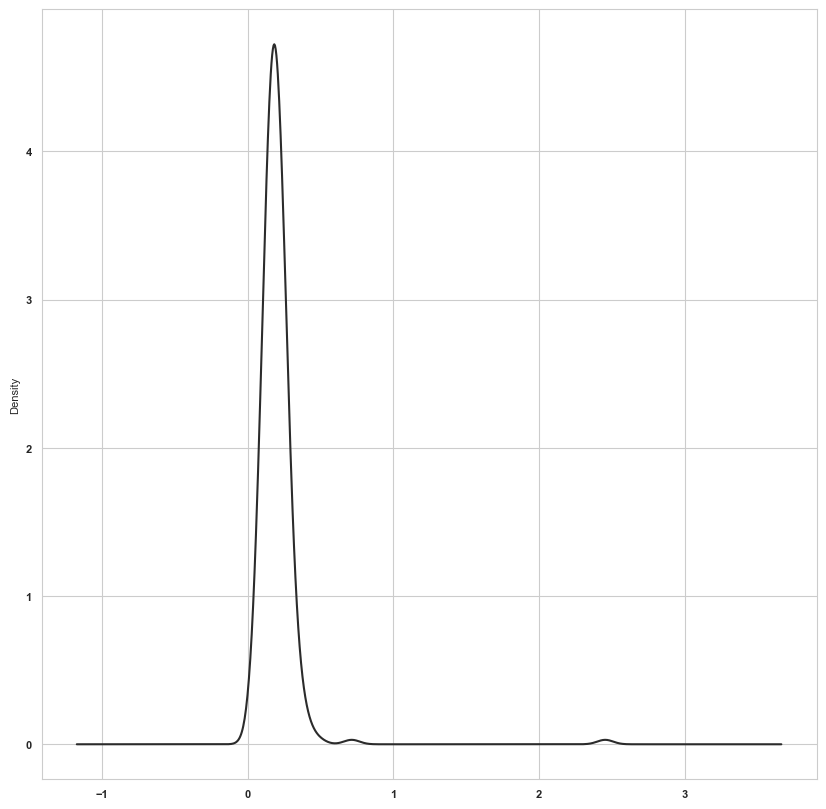

In [51]:
tips["tip_pct"].plot.density()

In [52]:
comp1=np.random.standard_normal(200)

In [53]:
comp1

array([ 0.7192927 , -0.51361524, -1.15554104, -0.20429459,  0.64704557,
       -0.3161853 ,  0.38692954,  1.46731233, -0.50004059, -0.08099107,
       -0.17006019, -1.1490891 , -0.1367508 , -0.30865661,  1.65587548,
        0.22086289, -2.38990713,  1.28936121, -0.26072822,  0.1135351 ,
       -0.24004289, -0.66333544, -2.01435299,  0.8377069 ,  0.18048034,
        0.53840395,  1.13663558, -2.025427  ,  0.06065648, -0.30334852,
       -0.61244355, -0.98427427,  0.71233841,  0.92359999,  0.05965394,
       -1.68349128, -0.30297019, -0.62019505, -0.16039703,  0.91674272,
        1.35112087, -0.95338252, -0.82076947,  0.77854543, -0.0818608 ,
        1.66916983, -0.60851132, -0.16838243,  0.70017673, -0.87653255,
       -0.94922341,  1.01477452,  0.91735132,  1.31620713, -1.33068946,
       -0.90542693, -0.55447739, -0.20056029,  1.02292388, -1.45802874,
       -0.8072592 ,  0.38664515,  1.37581422, -0.69702135,  0.1704691 ,
       -0.27795124,  0.87810629,  0.5170242 ,  0.07321063, -0.03

In [54]:
comp2=10+2*np.random.standard_normal(200)

In [55]:
comp2

array([10.02931402, 10.51429311,  8.8613182 ,  9.57789235,  5.5781665 ,
       12.08759706, 12.94372202, 10.47104788,  8.70330302,  9.1308885 ,
       11.83354304, 13.13708957,  9.93677475,  9.31349503, 11.18670906,
        9.97936867,  9.17280547,  6.55429009, 10.72821301, 13.13685389,
        8.68697681,  9.49888707, 11.01272385,  9.25057107, 11.68258035,
       11.90049245, 10.71754997,  9.14419425, 10.79247516,  7.95235563,
       12.19883887, 11.88829338, 10.88266545,  7.9113455 ,  7.75548192,
       10.55750366, 11.47265822, 11.84114787,  8.39455694, 11.97027533,
       10.74193181, 11.3525389 , 11.58562334, 12.43741024, 11.95854926,
       11.23387274, 10.85472949, 12.96667389, 11.52502218,  9.85891921,
       12.43688954,  7.80309836,  9.11072033, 12.45747565,  7.80432718,
        8.41461717, 11.15490239, 14.22886444, 11.0206654 , 12.30345796,
       13.80537432,  5.62582146, 14.41534815,  8.97150117, 11.64745791,
        5.89754723, 11.71541823, 10.0558119 , 10.51134782, 11.59

In [56]:
values=pd.Series(np.concatenate([comp1,comp2]))

<Axes: ylabel='Count'>

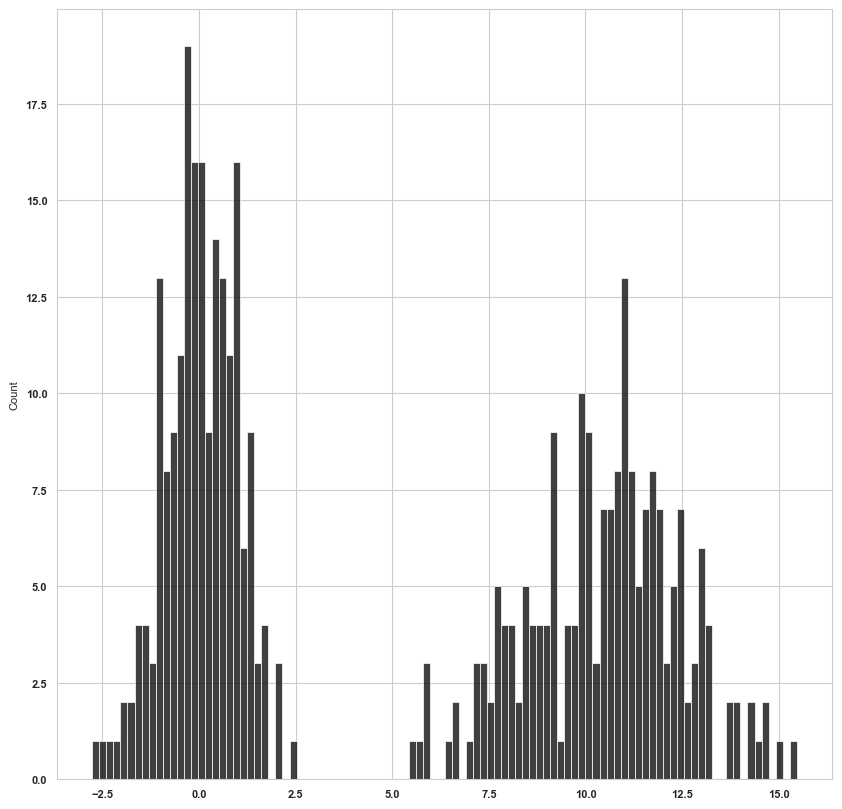

In [57]:
sns.histplot(values,bins=100,color="black")

# Scatter or Point Plots

In [58]:
macro=pd.read_csv("examples/macrodata.csv")

In [59]:
macro

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009,2,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [60]:
data=macro[["cpi","m1","tbilrate","unemp"]]

In [61]:
trans_data=np.log(data).diff().dropna()

In [62]:
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


TypeError: 'Text' object is not callable

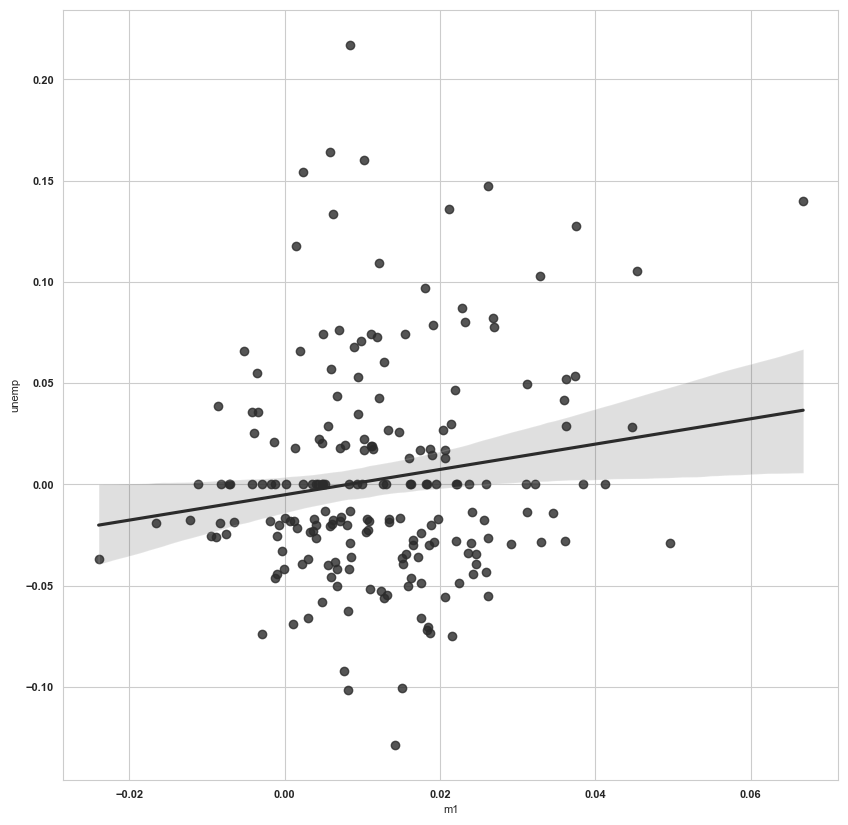

In [63]:
ax=sns.regplot(x="m1",y="unemp",data=trans_data)
ax.title("Changes in log(m1) versus log(unemp)")

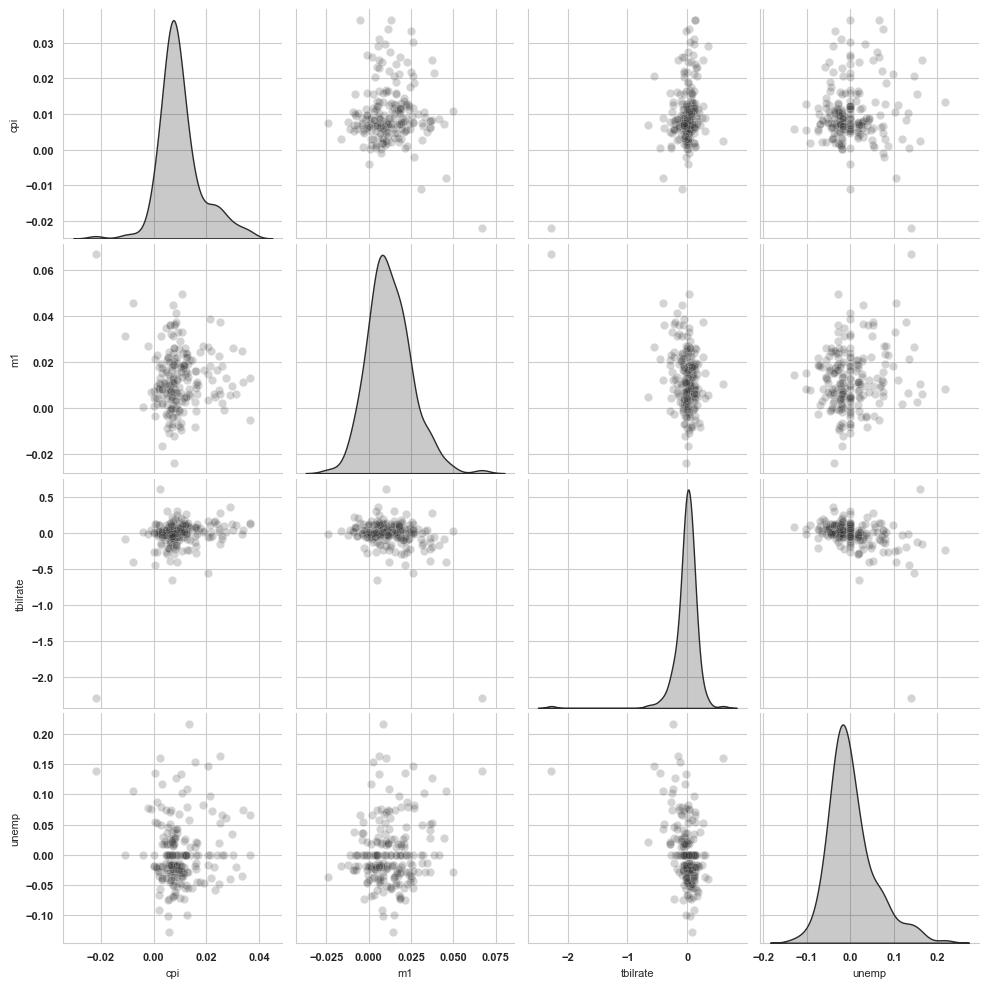

In [ ]:
sns.pairplot(trans_data,diag_kind="kde",plot_kws={"alpha":0.2})

# Facet Grids and Categorical Data

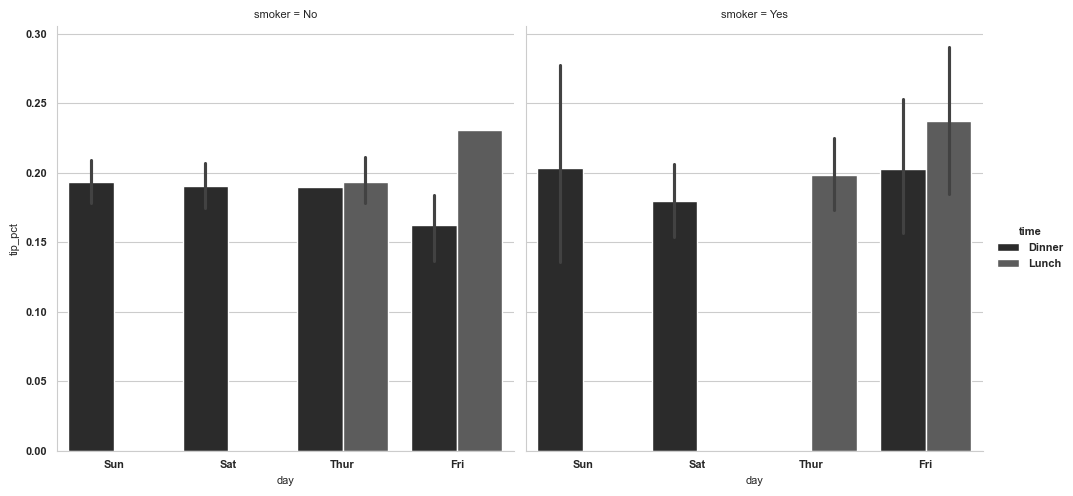

In [ ]:
sns.catplot(x="day",y="tip_pct",hue="time",col="smoker",kind="bar",data=tips[tips.tip_pct<1])

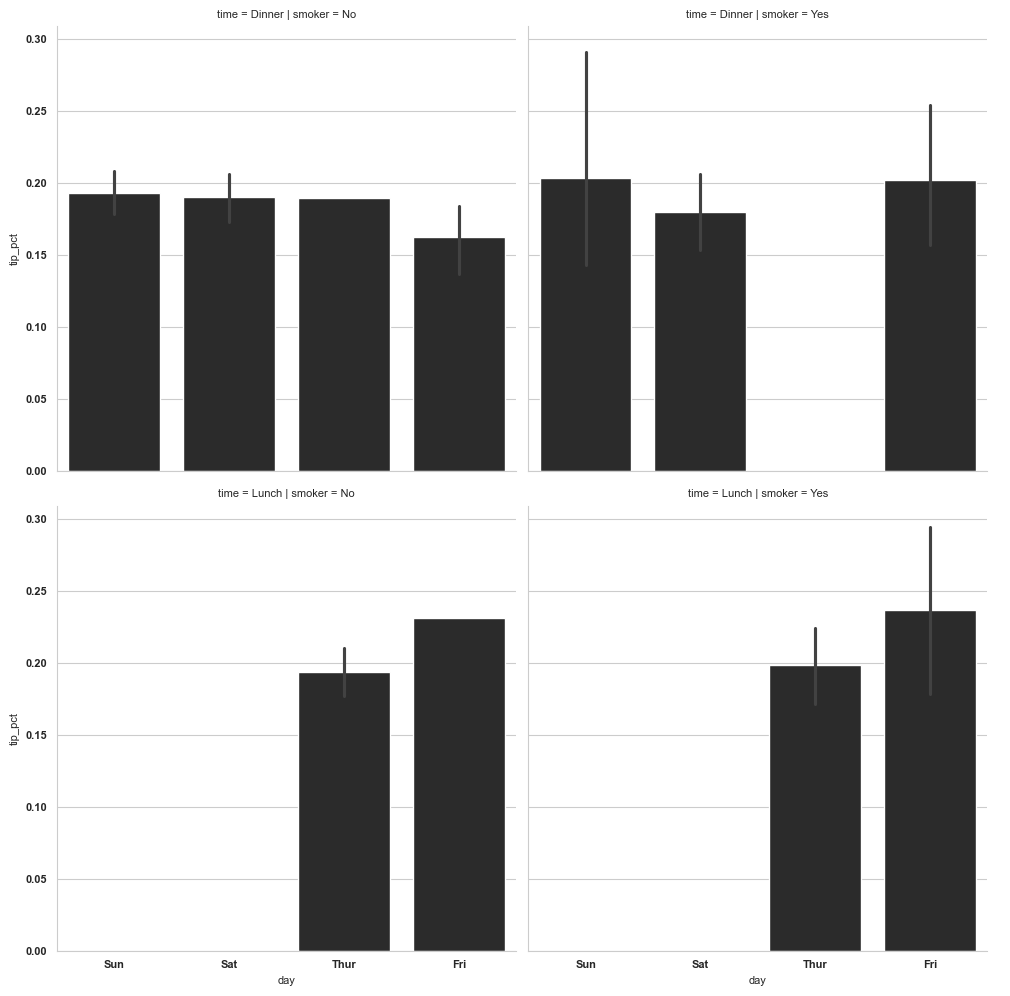

In [ ]:
sns.catplot(x="day",y="tip_pct",row="time",col="smoker",kind="bar",data=tips[tips.tip_pct<1])

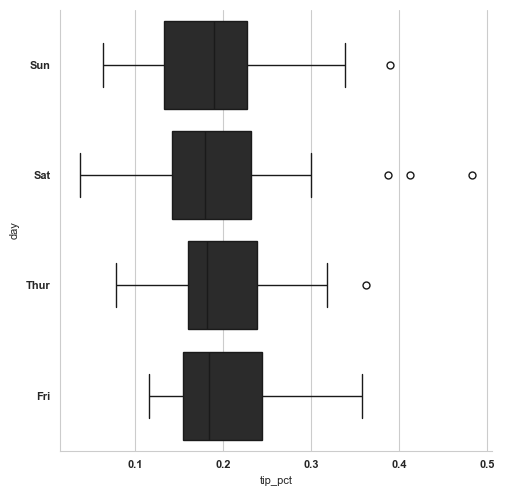

In [64]:
sns.catplot(x="tip_pct",y="day",kind="box",data=tips[tips.tip_pct<0.5])